# Phase 2: EDA & Hypothesis Testing
Phân tích dữ liệu bằng góc nhìn Thống kê và kiểm định giả thuyết khoa học. Tránh lỗi OOM nhờ khả năng Aggregation trước của DuckDB.

In [1]:
import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..')) if current_dir.endswith('notebooks') else current_dir
if project_root not in sys.path:
    sys.path.append(project_root)

from src.stat_tester import StatTester
tester = StatTester(os.path.join(project_root, 'dataraw'), os.path.join(project_root, 'dataclean'))

### Khảo sát Thành phố Chicago (Divvy Bike)


=== MÔ HÌNH URN: ĐÁNH GIÁ TÍNH ĐẠI DIỆN (DIVVY) ===
Bình nguyên bản (Urn - Population): Member 64.62%, Casual 35.38%
Mẫu rút ra (Sample S)          : Member 65.05%, Casual 34.95%
=> ĐỘ LỆCH 0.43% < 1%: KẾT LUẬN Mẫu (Sample) được trích xuất hoàn toàn mang tính đại diện, không bị thiên lệch (Unbiased), thỏa mãn điều kiện của Mô hình Urn.

=== PHÂN TÍCH PHÂN PHỐI (SKEWNESS) CHO DIVVY ===
1. Thống kê trung tâm:
   Mode (5) < Median (10.0) < Mean (14.93)
=> CHỨNG MINH: Dữ liệu bị Lệch phải rất mạnh (Right-skewed). Mean bị kéo lệch bởi các chuyến đi dài cực đoan.

2. Insight (Cú lừa của cấu trúc giá - Pricing Model Trick):
   Do chính sách đồng giá trong 30/45 phút đầu tiên, hành vi người dùng sẽ tạo thành một cụm vòm
   hoặc đi ngang ở vùng này trên biểu đồ, thay vì giảm tuyến tính theo cung cầu thuần túy.

Đang vẽ biểu đồ Grouped Histogram (sử dụng 1% Sample cho < 60 phút)...


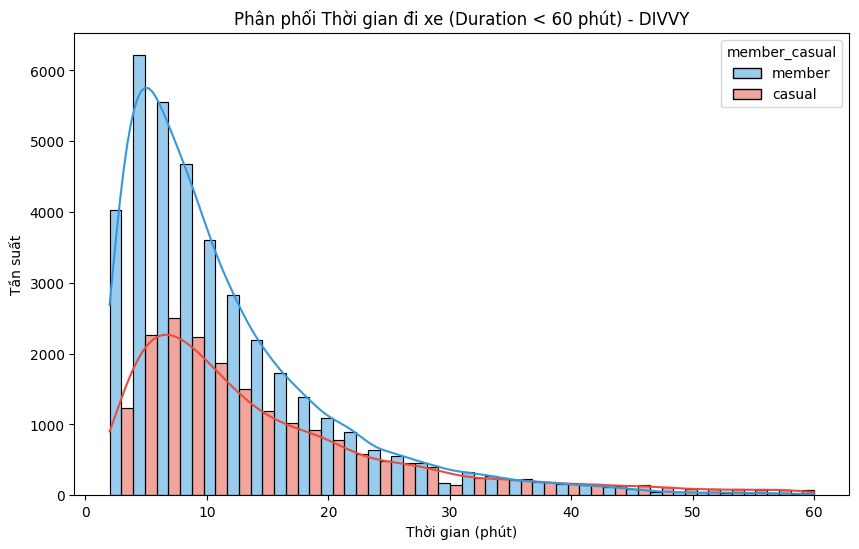


=== SUMMARY STATISTICS BOX PLOT CHO DIVVY ===


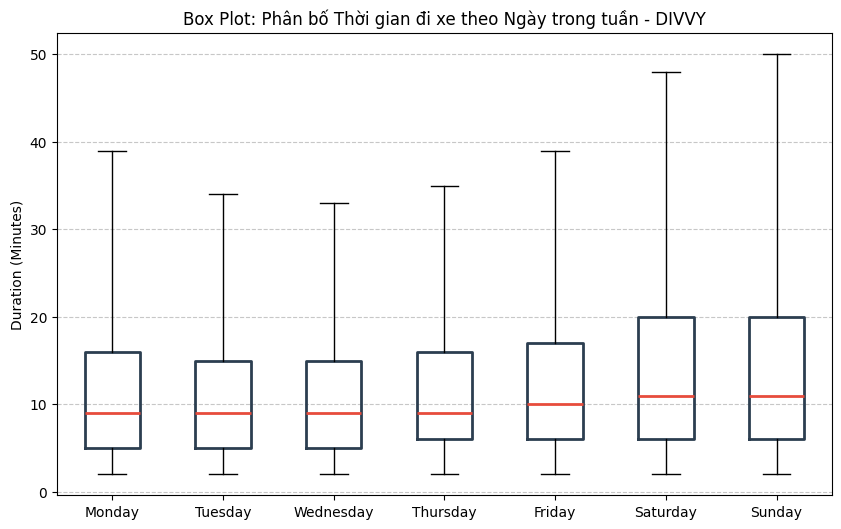


=== KIỂM ĐỊNH GIẢ THUYẾT (MANN-WHITNEY U) CHO DIVVY ===
Mean Casual (Sampled): 19.99 phút
Mean Member (Sampled): 12.21 phút

Thiết lập Giả thuyết:
H0: Mean_Casual <= Mean_Member (Khách vãng lai đi ít hoặc bằng thành viên)
HA: Mean_Casual > Mean_Member  (Khách vãng lai đi lâu hơn do mục đích du lịch/trải nghiệm)

Kết quả kiểm định:
- Mann-Whitney U statistic: 475116124.5
- p-value: 0.0

=> KẾT LUẬN CHÍNH THỨC: p-value < 0.05, BÁC BỎ H0.
   Khách vãng lai (Casual) có thời gian thuê xe trung bình lâu hơn đáng kể so với Member.
   Actionable Insight: Có cơ sở toán học để thiết kế các gói cước theo giờ/ngày cho khách vãng lai nhằm tối ưu doanh thu.


In [2]:
city = 'divvy'
raw_file = 'divvybike_merged.parquet'

# 1. Đánh giá tính đại diện của Mẫu so với Tổng thể (Urn Model)
tester.check_urn_model(city, raw_file)

# 2. Phân tích Phân phối dữ liệu (Lệch phải & Cú lừa cấu trúc giá)
tester.analyze_distribution(city)

# 3. Đo lường mức độ tập trung (Box Plot tránh OOM)
tester.plot_summary_boxplot(city)

# 4. Kiểm định Giả thuyết Hành vi Người dùng (Mann-Whitney U Test)
tester.run_mann_whitney_u(city)


=== MÔ HÌNH URN: ĐÁNH GIÁ TÍNH ĐẠI DIỆN (CITIBIKE) ===
Bình nguyên bản (Urn - Population): Member 82.52%, Casual 17.48%
Mẫu rút ra (Sample S)          : Member 82.38%, Casual 17.62%
=> ĐỘ LỆCH 0.14% < 1%: KẾT LUẬN Mẫu (Sample) được trích xuất hoàn toàn mang tính đại diện, không bị thiên lệch (Unbiased), thỏa mãn điều kiện của Mô hình Urn.

=== PHÂN TÍCH PHÂN PHỐI (SKEWNESS) CHO CITIBIKE ===
1. Thống kê trung tâm:
   Mode (5) < Median (9.0) < Mean (12.87)
=> CHỨNG MINH: Dữ liệu bị Lệch phải rất mạnh (Right-skewed). Mean bị kéo lệch bởi các chuyến đi dài cực đoan.

2. Insight (Cú lừa của cấu trúc giá - Pricing Model Trick):
   Do chính sách đồng giá trong 30/45 phút đầu tiên, hành vi người dùng sẽ tạo thành một cụm vòm
   hoặc đi ngang ở vùng này trên biểu đồ, thay vì giảm tuyến tính theo cung cầu thuần túy.

Đang vẽ biểu đồ Grouped Histogram (sử dụng 1% Sample cho < 60 phút)...


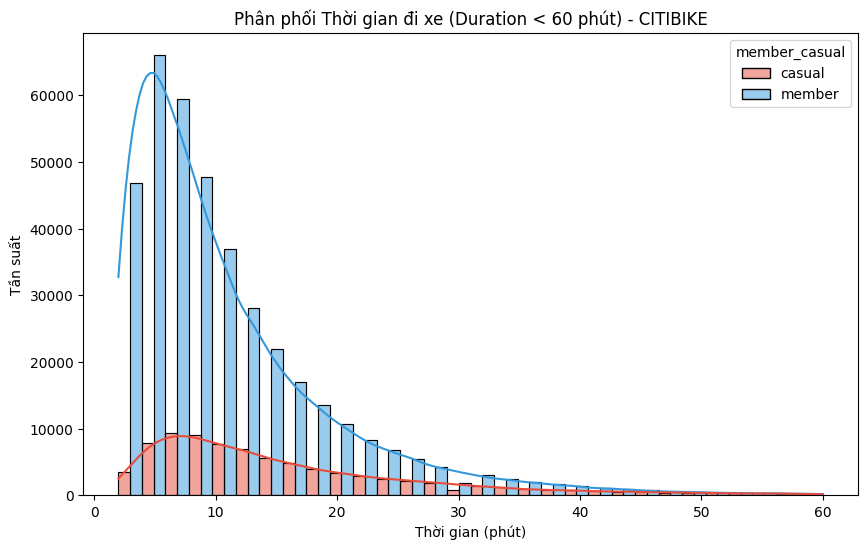


=== SUMMARY STATISTICS BOX PLOT CHO CITIBIKE ===


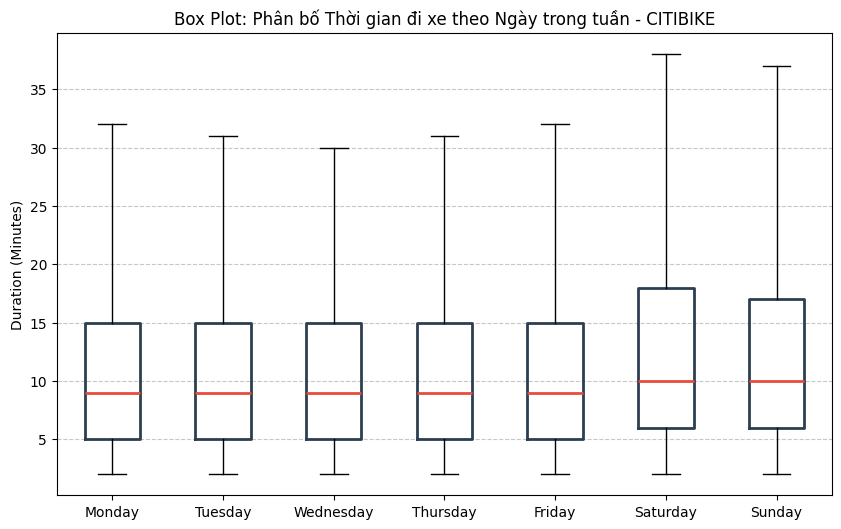


=== KIỂM ĐỊNH GIẢ THUYẾT (MANN-WHITNEY U) CHO CITIBIKE ===
Mean Casual (Sampled): 19.68 phút
Mean Member (Sampled): 11.41 phút

Thiết lập Giả thuyết:
H0: Mean_Casual <= Mean_Member (Khách vãng lai đi ít hoặc bằng thành viên)
HA: Mean_Casual > Mean_Member  (Khách vãng lai đi lâu hơn do mục đích du lịch/trải nghiệm)

Kết quả kiểm định:
- Mann-Whitney U statistic: 21515203455.5
- p-value: 0.0

=> KẾT LUẬN CHÍNH THỨC: p-value < 0.05, BÁC BỎ H0.
   Khách vãng lai (Casual) có thời gian thuê xe trung bình lâu hơn đáng kể so với Member.
   Actionable Insight: Có cơ sở toán học để thiết kế các gói cước theo giờ/ngày cho khách vãng lai nhằm tối ưu doanh thu.


In [3]:
city = 'citibike'
raw_file = 'citibike_nyc_merged.parquet'

# 1. Đánh giá tính đại diện của Mẫu so với Tổng thể (Urn Model)
tester.check_urn_model(city, raw_file)

# 2. Phân tích Phân phối dữ liệu (Lệch phải & Cú lừa cấu trúc giá)
tester.analyze_distribution(city)

# 3. Đo lường mức độ tập trung (Box Plot tránh OOM)
tester.plot_summary_boxplot(city)

# 4. Kiểm định Giả thuyết Hành vi Người dùng (Mann-Whitney U Test)
tester.run_mann_whitney_u(city)


=== MÔ HÌNH URN: ĐÁNH GIÁ TÍNH ĐẠI DIỆN (CAPITAL) ===
Bình nguyên bản (Urn - Population): Member 71.15%, Casual 28.85%
Mẫu rút ra (Sample S)          : Member 71.21%, Casual 28.79%
=> ĐỘ LỆCH 0.07% < 1%: KẾT LUẬN Mẫu (Sample) được trích xuất hoàn toàn mang tính đại diện, không bị thiên lệch (Unbiased), thỏa mãn điều kiện của Mô hình Urn.

=== PHÂN TÍCH PHÂN PHỐI (SKEWNESS) CHO CAPITAL ===
1. Thống kê trung tâm:
   Mode (5) < Median (10.0) < Mean (14.36)
=> CHỨNG MINH: Dữ liệu bị Lệch phải rất mạnh (Right-skewed). Mean bị kéo lệch bởi các chuyến đi dài cực đoan.

2. Insight (Cú lừa của cấu trúc giá - Pricing Model Trick):
   Do chính sách đồng giá trong 30/45 phút đầu tiên, hành vi người dùng sẽ tạo thành một cụm vòm
   hoặc đi ngang ở vùng này trên biểu đồ, thay vì giảm tuyến tính theo cung cầu thuần túy.

Đang vẽ biểu đồ Grouped Histogram (sử dụng 1% Sample cho < 60 phút)...


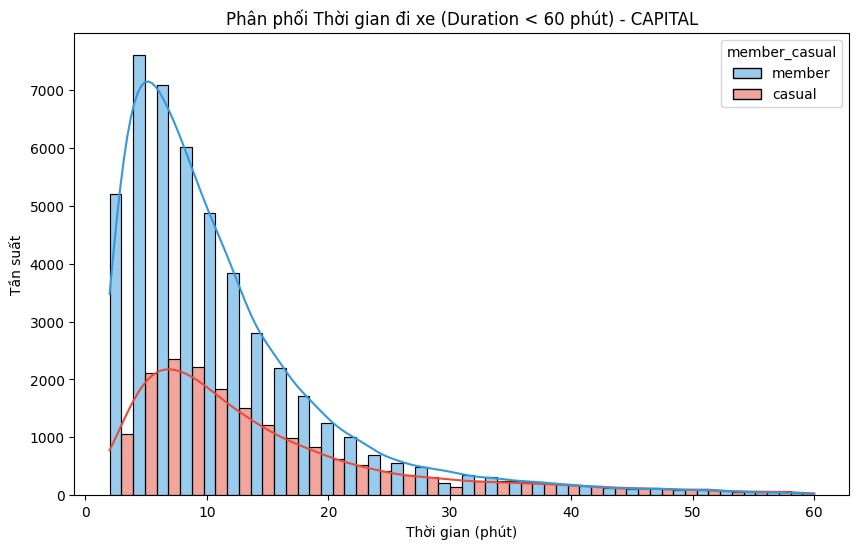


=== SUMMARY STATISTICS BOX PLOT CHO CAPITAL ===


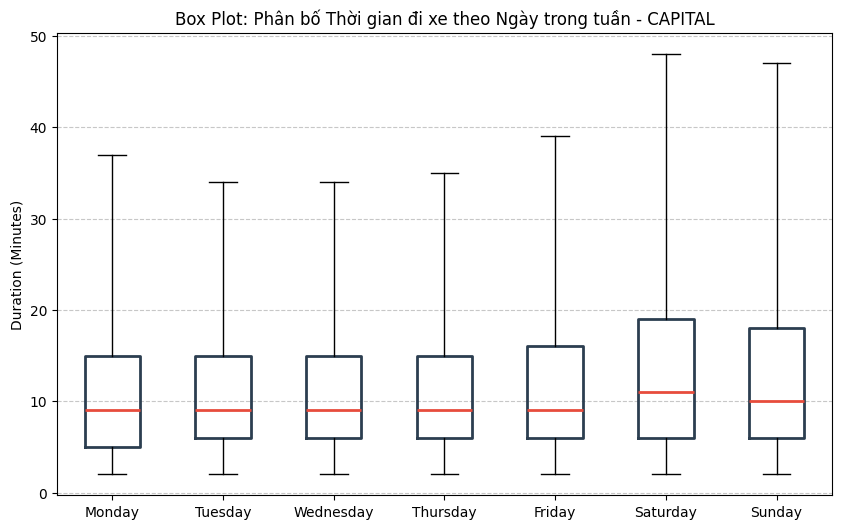


=== KIỂM ĐỊNH GIẢ THUYẾT (MANN-WHITNEY U) CHO CAPITAL ===
Mean Casual (Sampled): 19.99 phút
Mean Member (Sampled): 12.18 phút

Thiết lập Giả thuyết:
H0: Mean_Casual <= Mean_Member (Khách vãng lai đi ít hoặc bằng thành viên)
HA: Mean_Casual > Mean_Member  (Khách vãng lai đi lâu hơn do mục đích du lịch/trải nghiệm)

Kết quả kiểm định:
- Mann-Whitney U statistic: 565957427.5
- p-value: 0.0

=> KẾT LUẬN CHÍNH THỨC: p-value < 0.05, BÁC BỎ H0.
   Khách vãng lai (Casual) có thời gian thuê xe trung bình lâu hơn đáng kể so với Member.
   Actionable Insight: Có cơ sở toán học để thiết kế các gói cước theo giờ/ngày cho khách vãng lai nhằm tối ưu doanh thu.


In [4]:
city = 'capital'
raw_file = 'capitalbike_merged.parquet'

# 1. Đánh giá tính đại diện của Mẫu so với Tổng thể (Urn Model)
tester.check_urn_model(city, raw_file)

# 2. Phân tích Phân phối dữ liệu (Lệch phải & Cú lừa cấu trúc giá)
tester.analyze_distribution(city)

# 3. Đo lường mức độ tập trung (Box Plot tránh OOM)
tester.plot_summary_boxplot(city)

# 4. Kiểm định Giả thuyết Hành vi Người dùng (Mann-Whitney U Test)
tester.run_mann_whitney_u(city)